In [328]:
import numpy as np

import matplotlib.pyplot as plt
%config InlineBackend.figure_formats=['svg']
import pandas as pd

In [329]:
# Experiment #0: non private model training 
csv_path = '../data/output_non_private_model.csv'
df = pd.read_csv(csv_path)

best_epochs = df['best_epoch'].tolist()
early_stop_times = df['early_stop_time'].tolist()
ACC_train = df['train_acc'].tolist()
AUC_train = df['train_auc'].tolist()
ACC_test = df['test_acc'].tolist()
AUC_test = df['test_auc'].tolist()
avg_epoch_time = df['avg_epoch_time'].tolist()
std_epoch_time = df['std_epoch_time'].tolist()


In [330]:
print("\nModel Utility Summary:\n")

train_acc_mean = np.mean(ACC_train)
train_acc_std = np.std(ACC_train)
test_acc_mean = np.mean(ACC_test)
test_acc_std = np.std(ACC_test)
train_auc_mean = np.mean(AUC_train)
train_auc_std = np.std(AUC_train)
test_auc_mean = np.mean(AUC_test)
test_auc_std = np.std(AUC_test)

print(f"ACC (train): {train_acc_mean:.4f} ± {train_acc_std:.4f}")
print(f"ACC (test): {test_acc_mean:.4f} ± {test_acc_std:.4f}")
print()
print(f"AUC (train): {train_auc_mean:.4f} ± {train_auc_std:.4f}")
print(f"AUC (test): {test_auc_mean:.4f} ± {train_auc_std:.4f}")


Model Utility Summary:

ACC (train): 1.0000 ± 0.0000
ACC (test): 0.9478 ± 0.0018

AUC (train): 1.0000 ± 0.0000
AUC (test): 0.9967 ± 0.0000


In [331]:
print("\nModel Training Performance Summary:\n")
print(f"Average number of epochs: {np.mean(best_epochs):.1f} ± {np.std(best_epochs):.1f}")
print(f"Time before early stopping: {np.mean(early_stop_times):.1f} ± {np.std(early_stop_times):.1f} seconds")
print(f"Epoch time: {np.mean(avg_epoch_time):.3f} ± {np.std(std_epoch_time):.3f}")


Model Training Performance Summary:

Average number of epochs: 44.3 ± 3.3
Time before early stopping: 228.4 ± 15.6 seconds
Epoch time: 4.202 ± 0.003



In comparison, the same model trained with $(2, 7.0*10^{-9})$ DP-SGD and clipping $C=0.1259$

```
Model Utility Summary:

ACC (train): 0.7754  ± 0.0226
ACC (test): 0.7715 ± 0.0217

AUC (train): 0.9538 ± 0.0099
AUC (test): 0.9522 ± 0.0103


Model Training Performance Summary:

Average number of epochs: 51.0 ± 7.0
Time before early stopping: 360.33 ± 41.05 seconds
Epoch time: 5.91 ± 0.48 seconds

```
(see dpsgd_training.ipynb) 

In [332]:
# Experiment 1: effect of clipping 
# Privacy parameters: (2, 7.0e-09)

csv_path = '../data/output_find_clipping.csv'
df = pd.read_csv(csv_path)
EPSILON = 2 

clipping_params = df['clipping_param'].unique().tolist()
best_epochs = df.groupby("clipping_param")["best_epoch"].mean().tolist()
std_best_epochs = df.groupby("clipping_param")["best_epoch"].std().tolist()

early_stop_times = df.groupby("clipping_param")["early_stop_time"].mean().tolist() 
std_early_stop_times = df.groupby("clipping_param")["early_stop_time"].std().tolist() 

ACC_train = df.groupby("clipping_param")["train_acc"].mean().tolist()  
std_ACC_train =  df.groupby("clipping_param")["train_acc"].std().tolist()  

AUC_train = df.groupby("clipping_param")["train_auc"].mean().tolist() 
std_AUC_train =  df.groupby("clipping_param")["train_auc"].std().tolist()  

ACC_test = df.groupby("clipping_param")["test_acc"].mean().tolist()
std_ACC_test =  df.groupby("clipping_param")["train_acc"].std().tolist() 

AUC_test = df.groupby("clipping_param")["test_auc"].mean().tolist() 
std_AUC_test =  df.groupby("clipping_param")["train_auc"].std().tolist() 

avg_epoch_time = df.groupby("clipping_param")["avg_epoch_time"].mean().tolist()  
std_epoch_time = df.groupby("clipping_param")["std_epoch_time"].mean().tolist()  

In [333]:
print("\nModel Training Performance Summary:\n")

print(f"Average number of epochs: {np.mean(df['best_epoch']):.1f} ± {np.std(df['best_epoch']):.1f}")
print(f"Time before early stopping: {np.mean(df['early_stop_time']):.1f}  ± {np.std(df['early_stop_time']):.1f} seconds")
print(f"Epoch time: {np.mean(df['avg_epoch_time']):.3f} ± {np.std(df['avg_epoch_time']):.3f}")


Model Training Performance Summary:

Average number of epochs: 48.3 ± 6.4
Time before early stopping: 323.4  ± 35.1 seconds
Epoch time: 5.550 ± 0.088


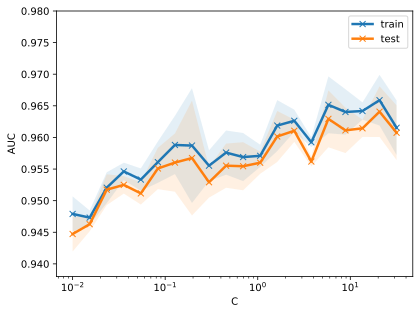

In [334]:
plt.plot(clipping_params, AUC_train, 'x-', linewidth=2.5, label='train')

plt.fill_between(clipping_params, 
                 [a - s for a, s in zip(AUC_train, std_AUC_train)], 
                 [a + s for a, s in zip(AUC_train, std_AUC_train)], 
                 alpha=0.12)

plt.plot(clipping_params, AUC_test,'x-',linewidth=2.5, label='test')
plt.fill_between(clipping_params, 
                 [a - s for a, s in zip(AUC_test, std_AUC_test)], 
                 [a + s for a, s in zip(AUC_test, std_AUC_test)], 
                 alpha=0.12)

plt.xlabel('C')
plt.ylabel('AUC')
plt.xscale('log')
plt.ylim(0.938, 0.98)
plt.legend();
plt.savefig(f"AUC_vs_C_epsilon={EPSILON}.png", dpi=300)

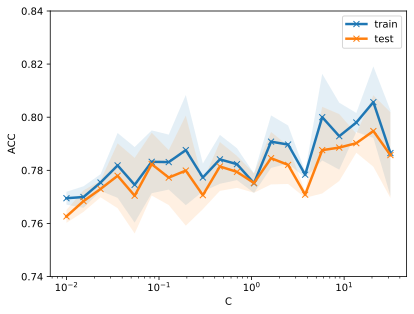

In [335]:
plt.plot(clipping_params, ACC_train, 'x-', linewidth=2.5, label='train')
plt.fill_between(clipping_params, 
                 [a - s for a, s in zip(ACC_train, std_ACC_train)], 
                 [a + s for a, s in zip(ACC_train, std_ACC_train)], 
                 alpha=0.12)

plt.plot(clipping_params, ACC_test,'x-', linewidth=2.5, label='test')
plt.fill_between(clipping_params, 
                 [a - s for a, s in zip(ACC_test, std_ACC_test)], 
                 [a + s for a, s in zip(ACC_test, std_ACC_test)], 
                 alpha=0.12)

plt.xlabel('C')
plt.ylabel('ACC')
plt.xscale('log')
plt.ylim(0.74, 0.84)

plt.legend();
plt.savefig(f"ACC_vs_C_epsilon={EPSILON}.png", dpi=300)

In [336]:
print("ACC gain: ",(max(ACC_test) - 0.7715)*100, "pp")

ACC gain:  2.329684302835422 pp


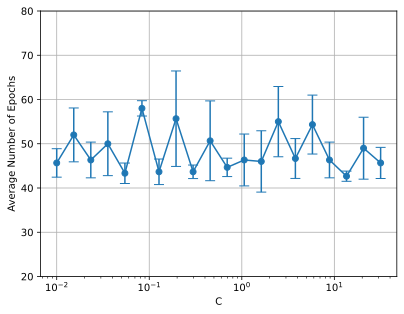

In [337]:
plt.errorbar(
    clipping_params,
    best_epochs,
    yerr=std_best_epochs,
    fmt='-o',
    capsize=5,
    capthick=1,
    
)
plt.grid()
plt.xlabel('C')
plt.xscale('log')
plt.ylim(20, 80)
plt.ylabel('Average Number of Epochs')

plt.savefig(f"NumEpochs_vs_C_epsilon={EPSILON}.png", dpi=300)

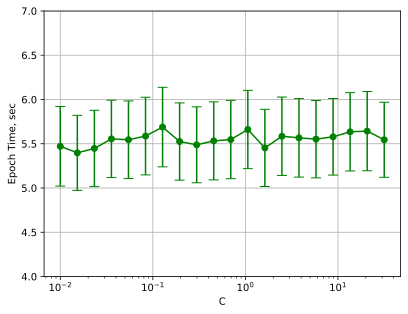

In [338]:
plt.errorbar(
    clipping_params,
    avg_epoch_time,
    yerr=std_epoch_time,
    fmt='-go',
    capsize=5,
    capthick=1,
    
)

plt.grid()
plt.xlabel('C')
plt.xscale('log')
plt.ylim(4, 7)
plt.ylabel('Epoch Time, sec');

plt.savefig(f"Epoch_Time_vs_C_epsilon={EPSILON}.png", dpi=300)

In [339]:
# Experiment #2: effect of the allocated privacy budget
# Privacy parameters: (2, 7.0e-09)
# BATCH_SIZE = 128
# lr = 0.001

C = 20.6914
csv_path = '../data/output_effect_of_epsilon.csv'
df = pd.read_csv(csv_path)

# print("Summary statistics:")
# print(df.describe())
# print(f"\nNumber of model initializations: {len(df)}")

# Convert columns to lists for plotting
main_var_name = 'epsilon_param'
epsilon_params = df[main_var_name].unique().tolist()
best_epochs = df.groupby(main_var_name)["best_epoch"].mean().tolist()
std_best_epochs = df.groupby(main_var_name)["best_epoch"].std().tolist()

early_stop_times = df.groupby(main_var_name)["early_stop_time"].mean().tolist() 
std_early_stop_times = df.groupby(main_var_name)["early_stop_time"].std().tolist() 

ACC_train = df.groupby(main_var_name)["train_acc"].mean().tolist()  
std_ACC_train =  df.groupby(main_var_name)["train_acc"].std().tolist()  

AUC_train = df.groupby(main_var_name)["train_auc"].mean().tolist() 
std_AUC_train =  df.groupby(main_var_name)["train_auc"].std().tolist()  

ACC_test = df.groupby(main_var_name)["test_acc"].mean().tolist()
std_ACC_test =  df.groupby(main_var_name)["train_acc"].std().tolist() 

AUC_test = df.groupby(main_var_name)["test_auc"].mean().tolist() 
std_AUC_test =  df.groupby(main_var_name)["train_auc"].std().tolist() 

avg_epoch_time = df.groupby(main_var_name)["avg_epoch_time"].mean().tolist()  
std_epoch_time = df.groupby(main_var_name)["std_epoch_time"].mean().tolist()  

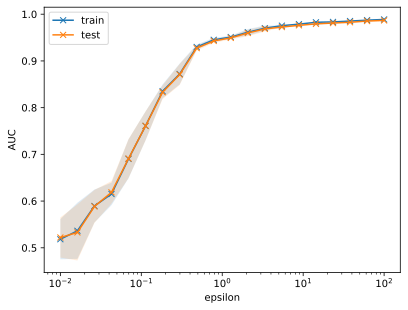

In [340]:
plt.plot(epsilon_params, AUC_train, 'x-', label='train')
plt.fill_between(epsilon_params, 
                 [a - s for a, s in zip(AUC_train, std_AUC_train)], 
                 [a + s for a, s in zip(AUC_train, std_AUC_train)], 
                 alpha=0.15)

plt.plot(epsilon_params, AUC_test,'x-', label='test')
plt.fill_between(epsilon_params, 
                 [a - s for a, s in zip(AUC_test, std_AUC_test)], 
                 [a + s for a, s in zip(AUC_test, std_AUC_test)], 
                 alpha=0.15)

plt.xlabel('epsilon')
plt.ylabel('AUC')
plt.xscale('log')
plt.legend();
plt.savefig(f"AUC_vs_epsilon_C={C}.png", dpi=300)

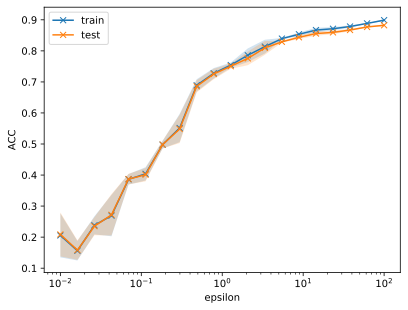

In [341]:
plt.plot(epsilon_params, ACC_train, 'x-', label='train')
plt.fill_between(epsilon_params, 
                 [a - s for a, s in zip(ACC_train, std_ACC_train)], 
                 [a + s for a, s in zip(ACC_train, std_ACC_train)], 
                 alpha=0.2)

plt.plot(epsilon_params, ACC_test,'x-', label='test')
plt.fill_between(epsilon_params, 
                 [a - s for a, s in zip(ACC_test, std_ACC_test)], 
                 [a + s for a, s in zip(ACC_test, std_ACC_test)], 
                 alpha=0.2)

plt.xlabel('epsilon')
plt.ylabel('ACC')
plt.xscale('log')
plt.legend();
plt.savefig(f"ACC_vs_epsilon_C={C}.png", dpi=300)

In [342]:
print(f"Max achieved ACC = {round(max(ACC_test),4)}")
print(f"Max achieved AUC = {round(max(AUC_test),4)}")

Max achieved ACC = 0.8824
Max achieved AUC = 0.9866


In [343]:
epsilon = epsilon_params[11]
print(f"Achieved ACC for the fixed epsilon = {epsilon:.2f} is {round(df[df['epsilon_param']==epsilon]['test_acc'].mean() ,4)} ± {round(df[df['epsilon_param']==epsilon]['test_acc'].std() ,4)}")
print(f"Achieved AUC for the fixed epsilon = {epsilon:.2f} is {round(df[df['epsilon_param']==epsilon]['test_auc'].mean() ,4)} ± {round(df[df['epsilon_param']==epsilon]['test_auc'].std() ,4)}")

Achieved ACC for the fixed epsilon = 2.07 is 0.7758 ± 0.0183
Achieved AUC for the fixed epsilon = 2.07 is 0.9598 ± 0.0063


In [344]:
print("\nModel Training Performance Summary:\n")


print(f"Average number of epochs: {np.mean(df['best_epoch']):.1f} ± {np.std(df['best_epoch']):.1f}")
print(f"Time before early stopping: {np.mean(df['early_stop_time']):.1f}  ± {np.std(df['early_stop_time']):.1f} seconds")
print(f"Epoch time: {np.mean(df['avg_epoch_time']):.3f} ± {np.std(df['avg_epoch_time']):.3f}")


Model Training Performance Summary:

Average number of epochs: 46.5 ± 4.5
Time before early stopping: 320.3  ± 26.7 seconds
Epoch time: 5.673 ± 0.096


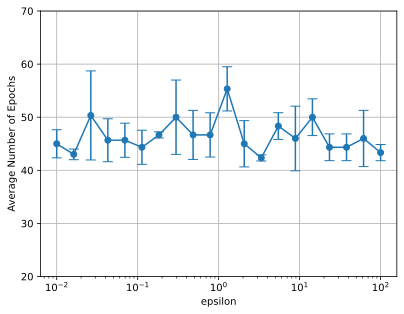

In [345]:
plt.errorbar(
    epsilon_params,
    best_epochs,
    yerr=std_best_epochs,
    fmt='-o',
    capsize=5,
    capthick=1,
)
plt.grid()
plt.xlabel('epsilon')
plt.xscale('log')
plt.ylabel('Average Number of Epochs')
plt.ylim(20,70)
plt.savefig(f"NumEpochs_vs_epsilon_C={C}.png", dpi=300)

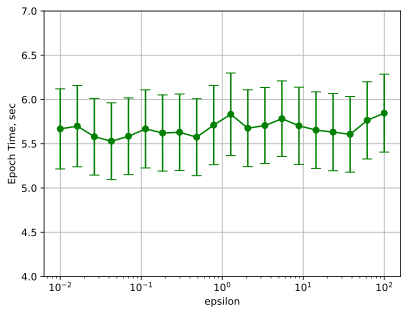

In [346]:
plt.errorbar(
    epsilon_params,
    avg_epoch_time,
    yerr=std_epoch_time,
    fmt='-go',
    capsize=5,
    capthick=1,
    
)

plt.grid()
plt.xlabel('epsilon')
plt.xscale('log')
plt.ylim(4,7)
plt.ylabel('Epoch Time, sec');

plt.savefig(f"Epoch_Time_vs_epsilon_C={C}.png", dpi=300)

In [347]:
# Experiment #3: effect of learning rate
# Privacy parameters: (2, 7.0e-09)
# BATCH_SIZE = 128
# C = 20.6914 

csv_path = '../data/output_effect_of_learning_rate.csv'
df = pd.read_csv(csv_path)

# print("Summary statistics:")
# print(df.describe())
# print(f"\nNumber of model initializations: {len(df)}")

# Convert columns to lists for plotting
main_var_name = 'learning_rate'
learning_rate_params = df[main_var_name].unique().tolist()
best_epochs = df.groupby(main_var_name)["best_epoch"].mean().tolist()
std_best_epochs = df.groupby(main_var_name)["best_epoch"].std().tolist()

early_stop_times = df.groupby(main_var_name)["early_stop_time"].mean().tolist() 
std_early_stop_times = df.groupby(main_var_name)["early_stop_time"].std().tolist() 

ACC_train = df.groupby(main_var_name)["train_acc"].mean().tolist()  
std_ACC_train =  df.groupby(main_var_name)["train_acc"].std().tolist()  

AUC_train = df.groupby(main_var_name)["train_auc"].mean().tolist() 
std_AUC_train =  df.groupby(main_var_name)["train_auc"].std().tolist()  

ACC_test = df.groupby(main_var_name)["test_acc"].mean().tolist()
std_ACC_test =  df.groupby(main_var_name)["train_acc"].std().tolist() 

AUC_test = df.groupby(main_var_name)["test_auc"].mean().tolist() 
std_AUC_test =  df.groupby(main_var_name)["train_auc"].std().tolist() 

avg_epoch_time = df.groupby(main_var_name)["avg_epoch_time"].mean().tolist()  
std_epoch_time = df.groupby(main_var_name)["std_epoch_time"].mean().tolist()  

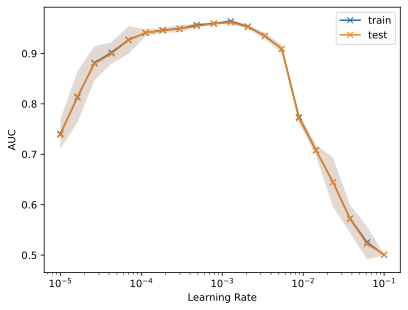

In [348]:
plt.plot(learning_rate_params, AUC_train, 'x-', label='train')
plt.fill_between(learning_rate_params, 
                 [a - s for a, s in zip(AUC_train, std_AUC_train)], 
                 [a + s for a, s in zip(AUC_train, std_AUC_train)], 
                 alpha=0.15)

plt.plot(learning_rate_params, AUC_test,'x-', label='test')
plt.fill_between(learning_rate_params, 
                 [a - s for a, s in zip(AUC_test, std_AUC_test)], 
                 [a + s for a, s in zip(AUC_test, std_AUC_test)], 
                 alpha=0.15)

plt.xlabel('Learning Rate')
plt.ylabel('AUC')
plt.xscale('log')
plt.legend();
plt.savefig(f"AUC_vs_lr_C={C}.png", dpi=300)

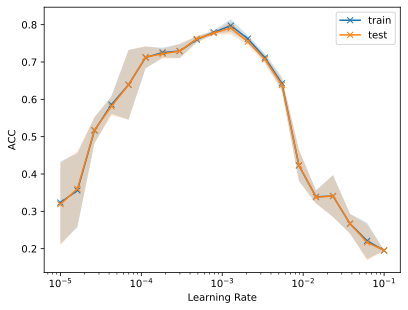

In [349]:
plt.plot(learning_rate_params, ACC_train, 'x-', label='train')
plt.fill_between(learning_rate_params, 
                 [a - s for a, s in zip(ACC_train, std_ACC_train)], 
                 [a + s for a, s in zip(ACC_train, std_ACC_train)], 
                 alpha=0.2)

plt.plot(learning_rate_params, ACC_test,'x-', label='test')
plt.fill_between(learning_rate_params, 
                 [a - s for a, s in zip(ACC_test, std_ACC_test)], 
                 [a + s for a, s in zip(ACC_test, std_ACC_test)], 
                 alpha=0.2)

plt.xlabel('Learning Rate')
plt.ylabel('ACC')
plt.xscale('log')
plt.legend();
plt.savefig(f"ACC_vs_lr_C={C}.png", dpi=300)

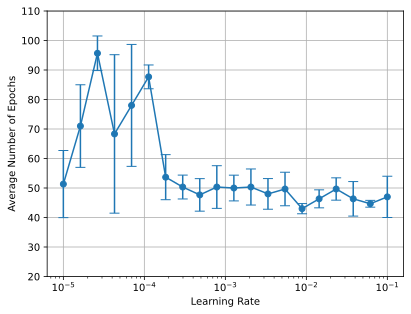

In [350]:
plt.errorbar(
    learning_rate_params,
    best_epochs,
    yerr=std_best_epochs,
    fmt='-o',
    capsize=5,
    capthick=1,
)
plt.grid()
plt.xlabel('Learning Rate')
plt.xscale('log')
plt.ylabel('Average Number of Epochs')
plt.ylim(20,110)
plt.savefig(f"NumEpochs_vs_lr_C={C}.png", dpi=300)


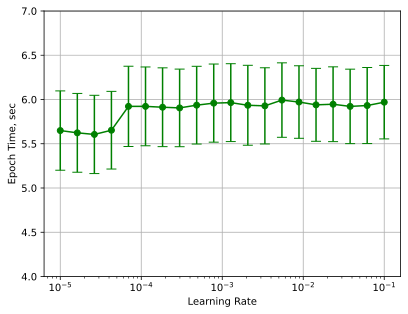

In [351]:
plt.errorbar(
    learning_rate_params,
    avg_epoch_time,
    yerr=std_epoch_time,
    fmt='-go',
    capsize=5,
    capthick=1,
    
)

plt.grid()
plt.xlabel('Learning Rate')
plt.xscale('log')
plt.ylim(4,7)
plt.ylabel('Epoch Time, sec');

plt.savefig(f"Epoch_Time_vs_lr_C={C}.png", dpi=300)

In [364]:
# Experiment #4 effect of batch size

# Epsilon = 2, delta = 7*10^(-9), clipping = 20.6914  LR = 0.00127

csv_path = '../data/output_effect_of_batch_size.csv'
df = pd.read_csv(csv_path)

# print("Summary statistics:")
# print(df.describe())
# print(f"\nNumber of model initializations: {len(df)}")

# Convert columns to lists for plotting
main_var_name = 'batch_size'
batch_sizes = np.sort(df[main_var_name].unique().tolist())
best_epochs = df.groupby(main_var_name)["best_epoch"].mean().tolist()
std_best_epochs = df.groupby(main_var_name)["best_epoch"].std().tolist()

early_stop_times = df.groupby(main_var_name)["early_stop_time"].mean().tolist() 
std_early_stop_times = df.groupby(main_var_name)["early_stop_time"].std().tolist() 

ACC_train = df.groupby(main_var_name)["train_acc"].mean().tolist()  # returns sorted list by main_var_name
std_ACC_train =  df.groupby(main_var_name)["train_acc"].std().tolist()  

AUC_train = df.groupby(main_var_name)["train_auc"].mean().tolist() 
std_AUC_train =  df.groupby(main_var_name)["train_auc"].std().tolist()  

ACC_test = df.groupby(main_var_name)["test_acc"].mean().tolist()
std_ACC_test =  df.groupby(main_var_name)["train_acc"].std().tolist() 

AUC_test = df.groupby(main_var_name)["test_auc"].mean().tolist() 
std_AUC_test =  df.groupby(main_var_name)["train_auc"].std().tolist() 

avg_epoch_time = df.groupby(main_var_name)["avg_epoch_time"].mean().tolist()  
std_epoch_time = df.groupby(main_var_name)["std_epoch_time"].mean().tolist() 


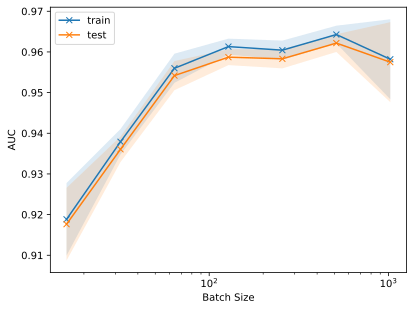

In [366]:
plt.plot(batch_sizes, AUC_train, 'x-', label='train')
plt.fill_between(batch_sizes, 
                 [a - s for a, s in zip(AUC_train, std_AUC_train)], 
                 [a + s for a, s in zip(AUC_train, std_AUC_train)], 
                 alpha=0.15)

plt.plot(batch_sizes, AUC_test,'x-', label='test')
plt.fill_between(batch_sizes, 
                 [a - s for a, s in zip(AUC_test, std_AUC_test)], 
                 [a + s for a, s in zip(AUC_test, std_AUC_test)], 
                 alpha=0.15)


plt.xlabel('Batch Size')
plt.xscale('log')
plt.ylabel('AUC')
plt.legend();
plt.savefig(f"AUC_vs_batch_size_C={C}_epsilon=2.png", dpi=300)


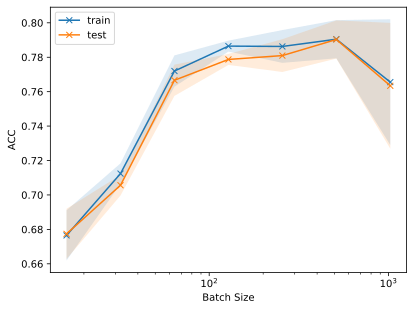

In [372]:
plt.plot(batch_sizes, ACC_train, 'x-', label='train')
plt.fill_between(batch_sizes, 
                 [a - s for a, s in zip(ACC_train, std_ACC_train)], 
                 [a + s for a, s in zip(ACC_train, std_ACC_train)], 
                 alpha=0.15)

plt.plot(batch_sizes, ACC_test,'x-', label='test')
plt.fill_between(batch_sizes, 
                 [a - s for a, s in zip(ACC_test, std_ACC_test)], 
                 [a + s for a, s in zip(ACC_test, std_ACC_test)], 
                 alpha=0.15)

plt.xlabel('Batch Size')
plt.xscale('log')
plt.ylabel('ACC')
plt.legend();
plt.savefig(f"ACC_vs_batch_size_C={C}_epsilon=2.png", dpi=300)

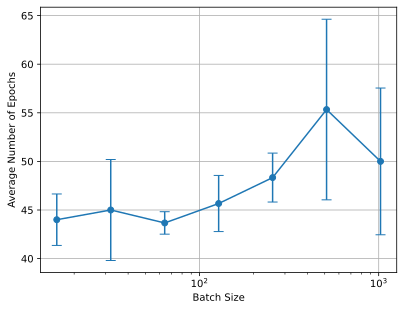

In [376]:
plt.errorbar(
    batch_sizes,
    best_epochs,
    yerr=std_best_epochs,
    fmt='-o',
    capsize=5,
    capthick=1,
)
plt.grid()
plt.xscale("log")
plt.xlabel('Batch Size')
plt.ylabel('Average Number of Epochs')

plt.savefig(f"NumEpochs_vs_batch_size_C={C}_epsilon=2.png", dpi=300)


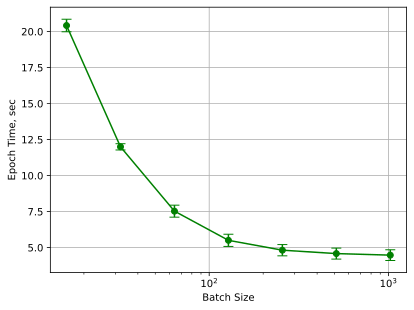

In [377]:
plt.errorbar(
    batch_sizes,
    avg_epoch_time,
    yerr=std_epoch_time,
    fmt='-go',
    capsize=5,
    capthick=1,
    
)

plt.grid()
plt.xlabel('Batch Size')
plt.xscale('log')
plt.ylabel('Epoch Time, sec');

plt.savefig(f"Epoch_Time_vs_batch_size_C={C}_epsilon=2.png", dpi=300)